# Mixture Model Fitting to the Exoplanet Dataset

We discuss the Gibbs sampler for fitting a Gaussian mixture models to the Exoplanet dataset. 

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pymc as pm
import scipy


The exoplanet dataset is downloaded from the NASA Exoplanet Archive. Some documentation describing each column, units and definitions is here: https://exoplanetarchive.ipac.caltech.edu/docs/API_PSCompPars_columns.html

In [ ]:
df = pd.read_csv("exoplanet_data.csv")
print(df.shape)
print(df.head(10))

(6128, 5)
         pl_name   pl_radj  pl_bmassj  pl_orbper  st_teff
0  Kepler-1167 b  0.152556    0.01120   1.003934   4971.0
1  Kepler-1740 b  0.296478    0.03470   8.172400   5705.0
2  Kepler-1581 b  0.071371    0.00137   6.283855   6022.0
3   Kepler-644 b  0.281024    0.03170   3.173917   6747.0
4  Kepler-1752 b  0.405086    0.05900  56.358501   5446.0
5   Kepler-280 c  0.179000    0.01480   4.807091   5744.0
6  Kepler-1208 b  0.206977    0.01890  11.085076   5001.0
7   Kepler-263 c  0.220000    0.02100  47.332773   5265.0
8  Kepler-1101 b  0.220359    0.02100  81.315106   5614.0
9    HD 168746 b  0.993000    0.27000   6.404000   5570.0


We shall work with the planet radii column. This column gives radius of each exoplanet as a multiple of the radius of Jupyter.

In [ ]:
print(df["pl_radj"].notna().sum())
print(df.shape[0])

6078
6128


 There are a few NA values for the planet radius, so we will drop those. We will also work with the logarithms of the data. 

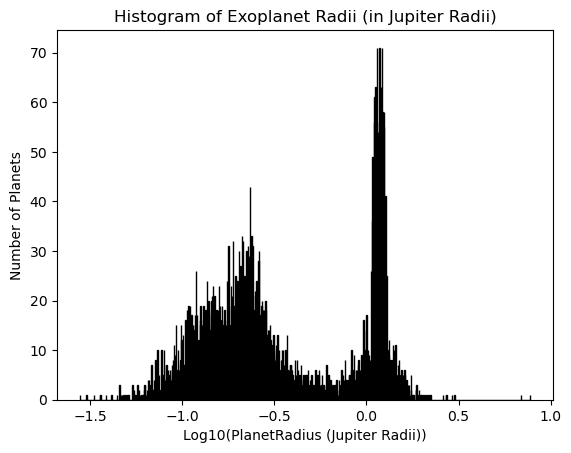

In [ ]:
rad_full = df['pl_radj'].dropna()
lograd_full = np.log10(rad_full)
lograd = lograd_full
plt.hist(lograd_full, bins=1000, edgecolor='black')
plt.title('Histogram of Exoplanet Radii (in Jupiter Radii)')
plt.xlabel('Log10(PlanetRadius (Jupiter Radii))')
plt.ylabel('Number of Planets')
plt.show()

We shall fit the $k$-component Gaussian mixture model: 
\begin{align*}
   \sum_{j=1}^k w_j N(\mu_j, \sigma_j^2). 
\end{align*}
using the Gibbs sampler. The unknown parameters are $(w_1, \dots, w_k)$ and $(\mu_j, \sigma_j^2)$ for $j = 1, \dots, k$. We shall use the following priors: 
\begin{align*}
  & (w_1, \dots, w_k) \sim \text{Dirichlet}(a_1, \dots, a_k) \\
  & \mu_1, \dots, \mu_k \overset{\text{i.i.d}}{\sim} N(m, s^2) \\
  & \sigma_1^2, \dots, \sigma_k^2 \overset{\text{i.i.d}}{\sim}
    IG(\alpha, \beta). 
\end{align*}
We will use the default choices are $a_j = 1$ for all $j$, $m = 0$ and $s^2$ to be
large, and $\alpha, \beta$ to be near zero.


Now let us implement the Gibbs sampler to fit this mixture model. The Gibbs sampler code is given below. 

1. Initialize the parameters $w^{(0)}, \mu^{(0)}, \sigma^{(0)}$.

2. Repeat the following for $t = 0, 1, 2, \dots$:

    a. Generate $z_1^{(t)}, \dots, z_n^{(t)}$ via:

    $$z_i^{(t)} \sim \text{Categorical} \left(\frac{w_j^{(t)} \phi \left(y_i, \mu^{(t)}_j, (\sigma_j^{(t)})^2 \right)}{\sum_{j=1}^k w_j^{(t)} \phi \left(y_i, \mu^{(t)}_j, (\sigma_j^{(t)})^2 \right)}, j = 1, \dots, k \right)$$

    b. Calculate

    $$n_j^{(t)} := \sum_{i=1}^n I\{z_i^{(t)} = j\} \quad \text{for } j = 1, \dots, k$$

    c. Generate $w^{(t+1)} = (w_1^{(t+1)}, \dots, w_k^{(t+1)})$ via

    $$w^{(t+1)} \sim \text{Dirichlet}(a_1 + n_1^{(t)}, \dots, a_k + n_k^{(t)})$$

    d. Generate $\mu_1^{(t+1)}, \dots, \mu_k^{(t+1)}$ via

    $$\mu_j^{(t+1)} \sim N \left(\frac{m/s^2 + \sum_{i : z^{(t)}_i = j} y_i/(\sigma_j^{(t)})^2}{1/s^2 + n_j^{(t)}/(\sigma_j^{(t)})^2}, \frac{1}{1/s^2 + n^{(t)}_j/(\sigma_j^{(t)})^2} \right)$$

    e. Generate $\sigma_1^{(t+1)}, \dots, \sigma_k^{(t+1)}$ via

    $$(\sigma_j^2)^{(t+1)} \sim IG \left(\alpha + \frac{n^{(t)}_j}{2}, \beta + \frac{1}{2} \sum_{i : z^{(t)}_i = j} (y_i - \mu^{(t+1)}_j)^2 \right)$$

Before implementing the Gibbs sampler, let us first observe that the code used in the previous lecture works with the special case $k = 2$ (i.e., it fits the two-component Gaussian mixture model). Here is the Gibbs sampler function used in last lecture. 

In [ ]:
from scipy.special import logsumexp

def gibbs_gmm(lograd, n_iter=10000,
              alpha_w=1, beta_w=1,
              mu_prior=np.array([0.0, 0.0]),
              tau_prior=np.array([30.0, 30.0]),
              a_sigma=0.0001, b_sigma=0.0001,
              random_seed=None):

    rng = np.random.default_rng(random_seed)
    y = np.asarray(lograd)
    N = len(y)

    mus = mu_prior.copy()
    sigmas = np.array([2.0, 2.0]) #initial values for sigma_0, sigma_1
    w = rng.beta(alpha_w, beta_w)   
    #w = alpha_w / (alpha_w + beta_w)

    z = rng.binomial(1, w, size=N)

    w_samples, mus_samples, sigmas_samples, z_samples = [], [], [], []

    for it in range(n_iter):
        logp0 = np.log(1 - w + 1e-300) - 0.5*np.log(2*np.pi*sigmas[0]**2) - 0.5*(y - mus[0])**2/sigmas[0]**2
        logp1 = np.log(w + 1e-300)     - 0.5*np.log(2*np.pi*sigmas[1]**2) - 0.5*(y - mus[1])**2/sigmas[1]**2
        p1 = np.exp(logp1 - logsumexp(np.vstack([logp0, logp1]), axis=0))
        z = rng.binomial(1, p1)

        n1 = z.sum()
        w = rng.beta(alpha_w + n1, beta_w + N - n1)

        for k in [0, 1]:
            yk = y[z == k]
            nk = len(yk)
            s2 = sigmas[k]**2
            tau2 = tau_prior[k]**2

            post_var = 1 / (1/tau2 + nk/s2)
            post_mean = post_var * (mu_prior[k]/tau2 + yk.sum()/s2)
            mus[k] = rng.normal(post_mean, np.sqrt(post_var))

            shape = a_sigma + nk/2
            scale = b_sigma + 0.5*np.sum((yk - mus[k])**2)
            s2_new = 1 / rng.gamma(shape, scale=1/scale)
            sigmas[k] = np.sqrt(s2_new)

        w_samples.append(w)
        mus_samples.append(mus.copy())
        sigmas_samples.append(sigmas.copy())
        z_samples.append(z.copy())

    return {
        "w": np.array(w_samples),
        "mus": np.array(mus_samples),
        "sigmas": np.array(sigmas_samples),
        "z": np.array(z_samples),
    }

samples_full = gibbs_gmm(lograd, n_iter=10000, random_seed=4)
burnin = 2000
samples_gibbs_2 = {k: v[burnin:] for k, v in samples_full.items()}

The trace plots of the parameters are given below. 

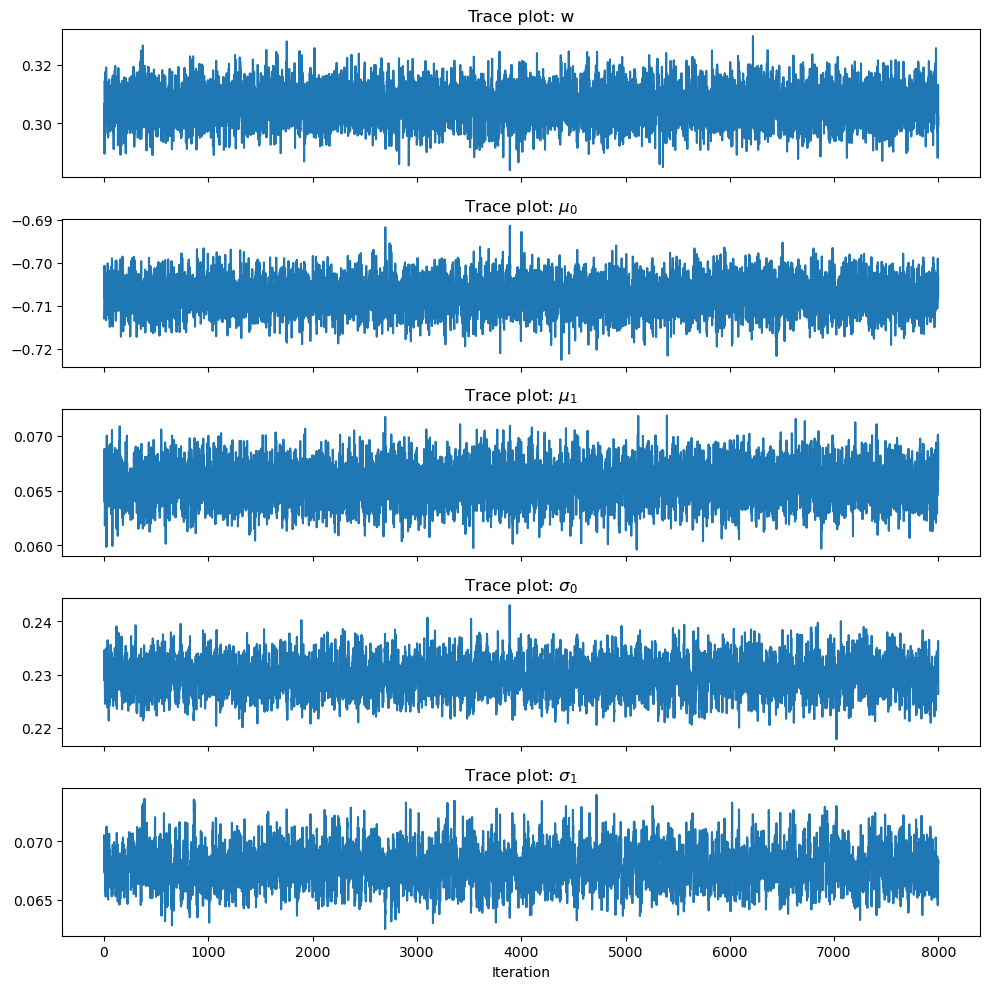

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(5, 1, figsize=(10, 10), sharex=True)

axes[0].plot(samples_gibbs_2["w"])
axes[0].set_title("Trace plot: w")

axes[1].plot(samples_gibbs_2["mus"][:, 0])
axes[1].set_title(r"Trace plot: $\mu_0$")

axes[2].plot(samples_gibbs_2["mus"][:, 1])
axes[2].set_title(r"Trace plot: $\mu_1$")

axes[3].plot(samples_gibbs_2["sigmas"][:, 0])
axes[3].set_title(r"Trace plot: $\sigma_0$")

axes[4].plot(samples_gibbs_2["sigmas"][:, 1])
axes[4].set_title(r"Trace plot: $\sigma_1$")

axes[4].set_xlabel("Iteration")
plt.tight_layout()
plt.show()

Here are the posterior means. 

In [ ]:
print("Posterior mean of w:", samples_gibbs_2["w"].mean())
print("Posterior mean of mu_0 and mu_1:", samples_gibbs_2["mus"].mean(axis=0))
print("Posterior mean of sigma_0 and sigma_1:", samples_gibbs_2["sigmas"].mean(axis=0))

Posterior mean of w: 0.30635621367574895
Posterior mean of mu_0 and mu_1: [-0.70748589  0.06563421]
Posterior mean of sigma_0 and sigma_1: [0.22961453 0.06784077]


Below we plot the fitted density corresponding to the posterior mean parameters on the histogram of the data. 

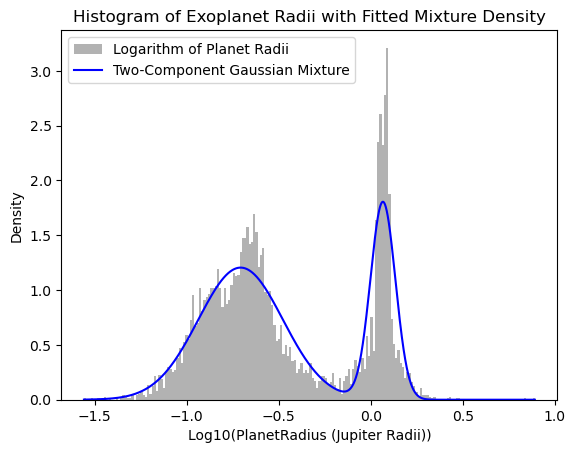

In [ ]:
#Plotting the fitted two component normal mixture density on the histogram
from scipy.stats import norm

plt.hist(lograd, bins = 200, density = True, alpha = 0.6, label = 'Logarithm of Planet Radii', color = 'gray')
x = np.linspace(lograd.min(), lograd.max(), 10000)
pdf_gibbs_2 = (1-samples_gibbs_2["w"].mean()) * norm.pdf(x, loc=samples_gibbs_2["mus"].mean(axis=0)[0], scale=samples_gibbs_2["sigmas"].mean(axis=0)[0]) + (samples_gibbs_2["w"].mean()) * norm.pdf(x, loc=samples_gibbs_2["mus"].mean(axis=0)[1], scale=samples_gibbs_2["sigmas"].mean(axis=0)[1])
plt.plot(x, pdf_gibbs_2, color='blue', label='Two-Component Gaussian Mixture')
plt.title('Histogram of Exoplanet Radii with Fitted Mixture Density')
plt.xlabel('Log10(PlanetRadius (Jupiter Radii))')
plt.ylabel('Density')
plt.legend()
plt.show()

Next we have the Gibbs sampler code for general $K$. 

In [ ]:
def gibbs_gmm_k(lograd, K, n_iter=10000,
                a_sigma=0.0001, b_sigma=0.0001,
                random_seed=None):

    rng = np.random.default_rng(random_seed)
    y = np.asarray(lograd, dtype=float)
    N = len(y)

    alpha_dirichlet = np.ones(K)
    mu_prior = np.zeros(K)
    tau_prior = np.full(K, 30.0)

    mus = mu_prior.copy()
    sigmas = np.full(K, 2.0)
    weights = rng.dirichlet(alpha_dirichlet)
    z = rng.choice(K, size=N, p=weights)

    weights_samples = np.empty((n_iter, K))
    mus_samples = np.empty((n_iter, K))
    sigmas_samples = np.empty((n_iter, K))
    z_samples = np.empty((n_iter, N), dtype=int)

    for it in range(n_iter):
        log_probs = np.array([
            np.log(weights[k] + 1e-300)
            - 0.5 * np.log(2 * np.pi * sigmas[k]**2)
            - 0.5 * (y - mus[k])**2 / sigmas[k]**2
            for k in range(K)
        ])

        probs = np.exp(log_probs - logsumexp(log_probs, axis=0))
        cumprobs = np.cumsum(probs, axis=0)
        z = np.sum(rng.random(N)[None, :] > cumprobs, axis=0)

        counts = np.bincount(z, minlength=K)
        weights = rng.dirichlet(alpha_dirichlet + counts)

        for k in range(K):
            yk = y[z == k]
            nk = len(yk)
            s2 = sigmas[k]**2
            tau2 = tau_prior[k]**2

            post_var = 1.0 / (1.0 / tau2 + nk / s2)
            post_mean = post_var * (mu_prior[k] / tau2 + yk.sum() / s2)
            mus[k] = rng.normal(post_mean, np.sqrt(post_var))

            shape = a_sigma + nk / 2.0
            scale = b_sigma + 0.5 * np.sum((yk - mus[k])**2)
            gamma_sample = rng.gamma(shape, scale=1.0 / scale)
            sigmas[k] = np.sqrt(1.0 / max(gamma_sample, 1e-20))
            #sigmas[k] = np.sqrt(1.0 / gamma_sample)

        weights_samples[it] = weights
        mus_samples[it] = mus
        sigmas_samples[it] = sigmas
        z_samples[it] = z

    return {
        "weights": weights_samples,
        "mus": mus_samples,
        "sigmas": sigmas_samples,
        "z": z_samples,
    }

First check that for $K = 2$, we get the same output as the function from last lecture. 

In [ ]:
K = 2
samples_full = gibbs_gmm_k(lograd, K = K,  n_iter=10000, random_seed=4)
burnin = 2000
samples_K = {k: v[burnin:] for k, v in samples_full.items()}

In [ ]:
weights_samples = samples_K["weights"]
mus_samples = samples_K["mus"]
sigmas_samples = samples_K["sigmas"]
z_samples = samples_K["z"]

Posterior mean of weights: [0.30635256 0.69364744]
Posterior mean of means: [ 0.06557599 -0.707342  ]
Posterior mean of standard deviations: [0.06781166 0.22968839]


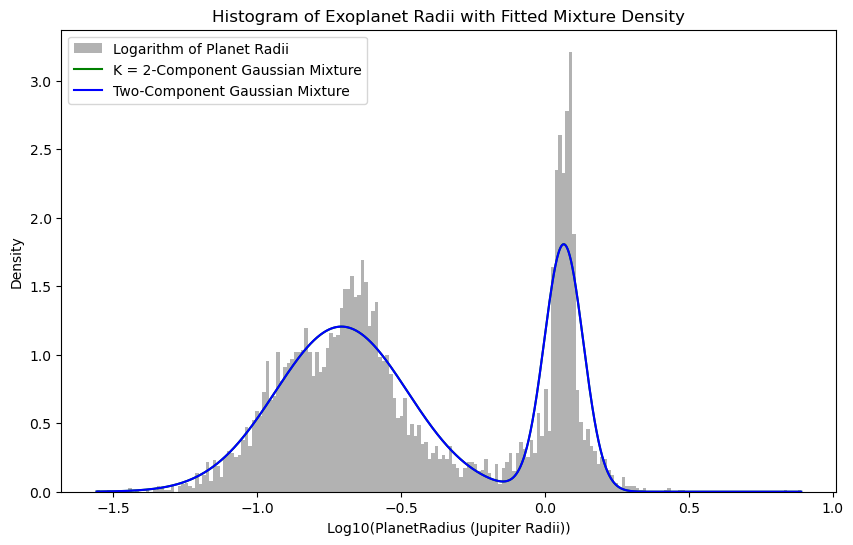

In [ ]:
from scipy.stats import norm

plt.figure(figsize=(10, 6))
plt.hist(lograd, bins=200, density=True, alpha=0.6, label='Logarithm of Planet Radii', color = 'gray')

x = np.linspace(lograd.min(), lograd.max(), 10000)

weights_mean = samples_K["weights"].mean(axis=0)
mus_mean = samples_K["mus"].mean(axis=0)
sigmas_mean = samples_K["sigmas"].mean(axis=0)

print("Posterior mean of weights:", weights_mean)
print("Posterior mean of means:", mus_mean)
print("Posterior mean of standard deviations:", sigmas_mean)

pdf_gibbs_K = sum(
    weights_mean[k] * norm.pdf(x, loc=mus_mean[k], scale=sigmas_mean[k])
    for k in range(len(weights_mean))
)

plt.plot(x, pdf_gibbs_K, color='green', label=f'K = {K}-Component Gaussian Mixture')
plt.plot(x, pdf_gibbs_2, color='blue', label='Two-Component Gaussian Mixture')
plt.title('Histogram of Exoplanet Radii with Fitted Mixture Density')
plt.xlabel('Log10(PlanetRadius (Jupiter Radii))')
plt.ylabel('Density')
plt.legend()
plt.show()

The two fits coincide. Now let us increase the value of $K$. 

Posterior mean of weights: [0.67107346 0.18861723 0.1403093 ]
Posterior mean of means: [-0.7260222   0.06822026  0.02813757]
Posterior mean of standard deviations: [0.20629314 0.02622899 0.14350059]


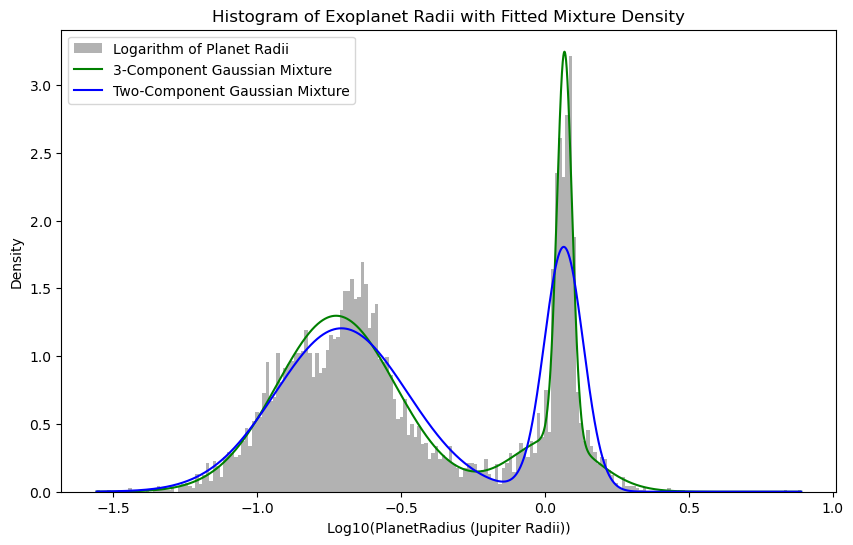

In [ ]:
K = 3
#K = 4
samples_full = gibbs_gmm_k(lograd, K = K,  n_iter=10000, random_seed=4)
burnin = 2000
samples_K = {k: v[burnin:] for k, v in samples_full.items()}

plt.figure(figsize=(10, 6))
plt.hist(lograd, bins=200, density=True, alpha=0.6, label='Logarithm of Planet Radii', color = 'gray')

x = np.linspace(lograd.min(), lograd.max(), 10000)

weights_mean = samples_K["weights"].mean(axis=0)
mus_mean = samples_K["mus"].mean(axis=0)
sigmas_mean = samples_K["sigmas"].mean(axis=0)

print("Posterior mean of weights:", weights_mean)
print("Posterior mean of means:", mus_mean)
print("Posterior mean of standard deviations:", sigmas_mean)

pdf_gibbs_K = sum(
    weights_mean[k] * norm.pdf(x, loc=mus_mean[k], scale=sigmas_mean[k])
    for k in range(len(weights_mean))
)

plt.plot(x, pdf_gibbs_K, color='green', label=f'{K}-Component Gaussian Mixture')
plt.plot(x, pdf_gibbs_2, color='blue', label='Two-Component Gaussian Mixture')
plt.title('Histogram of Exoplanet Radii with Fitted Mixture Density')
plt.xlabel('Log10(PlanetRadius (Jupiter Radii))')
plt.ylabel('Density')
plt.legend()
plt.show()

The fitted model with $K = 3$ gives a better fit to the histogram compared to $K = 2$. Further increasing $K$ to $K = 4$ does not seem to increase the quality of fit visually. We can go with $K = 3$ therefore. 

The Gaussian mixture model allows 'clustering' of the samples into different groups. This is done using the posterior samples corresponding to $z_1, \dots, z_n$. Each posterior sample of $z_i$ takes the discrete values $1, \dots, K$. We can take the posterior mode of these samples, and this will associate one index from $1, \dots, K$ to each $y_i$. All the observations $y_i$ for which the posterior mode of $z_i = j$ would form the cluster $j$. These clusters can be visualized as follows. 

Posterior mean of weights: [0.67107346 0.18861723 0.1403093 ]
Posterior mean of means: [-0.7260222   0.06822026  0.02813757]
Posterior mean of standard deviations: [0.20629314 0.02622899 0.14350059]


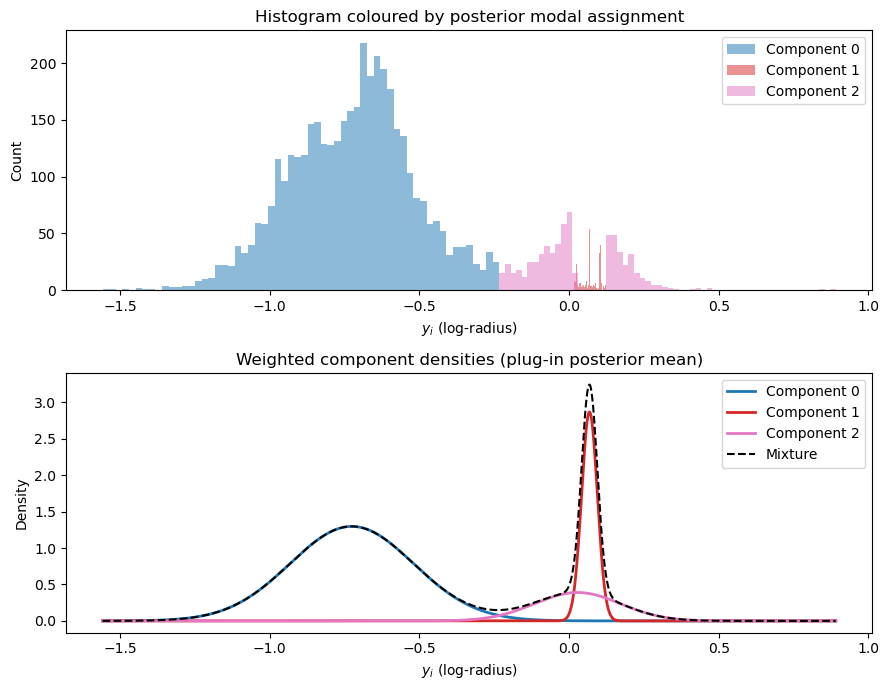

In [ ]:
K = 3
samples_full = gibbs_gmm_k(lograd, K = K,  n_iter=10000, random_seed=4)
burnin = 2000
samples_K = {k: v[burnin:] for k, v in samples_full.items()}

weights_samples = samples_K["weights"]
mus_samples = samples_K["mus"]
sigmas_samples = samples_K["sigmas"]
z_samples = samples_K["z"]

weights_mean = samples_K["weights"].mean(axis=0)
mus_mean = samples_K["mus"].mean(axis=0)
sigmas_mean = samples_K["sigmas"].mean(axis=0)


print("Posterior mean of weights:", weights_mean)
print("Posterior mean of means:", mus_mean)
print("Posterior mean of standard deviations:", sigmas_mean)

z_mode = scipy.stats.mode(z_samples, axis=0).mode  # shape (N,)

fig, axes = plt.subplots(2, 1, figsize=(9, 7))
colors = [plt.cm.tab10(k / K) for k in range(K)]
for k in range(K):
    axes[0].hist(lograd[z_mode == k], bins=60, alpha=0.5,
                 color=colors[k], label=f"Component {k}")
axes[0].set_xlabel("$y_i$ (log-radius)")
axes[0].set_ylabel("Count")
axes[0].legend()
axes[0].set_title("Histogram coloured by posterior modal assignment")

# --- Panel 2: overlay posterior predictive per component ---
x = np.linspace(lograd.min(), lograd.max(), 2000)
w_mean = weights_samples.mean(axis=0)          # shape (K,)
mu_mean = mus_samples.mean(axis=0)             # shape (K,)
sig_mean = sigmas_samples.mean(axis=0)         # shape (K,)

for k in range(K):
    axes[1].plot(x, w_mean[k] * norm.pdf(x, mu_mean[k], sig_mean[k]),
                 color=colors[k], lw=2, label=f"Component {k}")
axes[1].plot(x, sum(w_mean[k] * norm.pdf(x, mu_mean[k], sig_mean[k])
                    for k in range(K)),
             "k--", lw=1.5, label="Mixture")
axes[1].set_xlabel("$y_i$ (log-radius)")
axes[1].set_ylabel("Density")
axes[1].legend()
axes[1].set_title("Weighted component densities (plug-in posterior mean)")

plt.tight_layout()

## EM Algorithm

Let us now implement the EM algorithm which can be seen as a deterministic version of the Gibbs sampler (which does not use any priors). The code for the EM algorithm is given below. 
1. Initialize the parameters $w^{(0)}, \mu^{(0)}, \sigma^{(0)}$.

2. Repeat the following for $t = 0, 1, 2, \dots$ until convergence:

    a. **E-step.** Compute the responsibility of component $j$ for observation $i$:

    $$r_{ij}^{(t)} := \frac{w_j^{(t)} \phi\left(y_i, \mu_j^{(t)}, (\sigma_j^{(t)})^2\right)}{\sum_{l=1}^k w_l^{(t)} \phi\left(y_i, \mu_l^{(t)}, (\sigma_l^{(t)})^2\right)}, \quad j = 1, \dots, k.$$

    b. Compute the effective counts

    $$n_j^{(t)} := \sum_{i=1}^n r_{ij}^{(t)}, \quad j = 1, \dots, k.$$

    c. **M-step.** Update the weights:

    $$w_j^{(t+1)} := \frac{n_j^{(t)}}{n}, \quad j = 1, \dots, k.$$

    d. Update the means:

    $$\mu_j^{(t+1)} := \frac{\sum_{i=1}^n r_{ij}^{(t)}\, y_i}{n_j^{(t)}}, \quad j = 1, \dots, k.$$

    e. Update the variances:

    $$(\sigma_j^2)^{(t+1)} := \frac{\sum_{i=1}^n r_{ij}^{(t)} \left(y_i - \mu_j^{(t+1)}\right)^2}{n_j^{(t)}}, \quad j = 1, \dots, k.$$

This EM algorithm is implemented in the code below. 

In [ ]:
from scipy.special import logsumexp

def em_gmm_k(lograd, K, n_iter=10000, random_seed=None):
    rng = np.random.default_rng(random_seed)
    y = np.asarray(lograd, dtype=float)
    N = len(y)

    # --- nearly the same initialisation as Gibbs ---
    #mus = np.zeros(K) #with this initialization, EM does not work
    mus = rng.normal(loc=0.0, scale=1.0, size=K)
    sigmas = np.full(K, 2.0)
    weights = rng.dirichlet(np.ones(K))

    weights_samples = np.empty((n_iter, K))
    mus_samples     = np.empty((n_iter, K))
    sigmas_samples  = np.empty((n_iter, K))
    r_samples       = np.empty((n_iter, N, K))

    for it in range(n_iter):
        # --- E-step ---
        log_probs = np.array([
            np.log(weights[k] + 1e-300)
            - 0.5 * np.log(2 * np.pi * sigmas[k]**2)
            - 0.5 * (y - mus[k])**2 / sigmas[k]**2
            for k in range(K)
        ])
        log_r = log_probs - logsumexp(log_probs, axis=0)
        r = np.exp(log_r)

        # effective counts
        nk = r.sum(axis=1)

        # --- M-step ---
        weights = nk / N
        for k in range(K):
            mus[k]    = (r[k] * y).sum() / nk[k]
            sigmas[k] = np.sqrt((r[k] * (y - mus[k])**2).sum() / nk[k])

        weights_samples[it] = weights
        mus_samples[it]     = mus
        sigmas_samples[it]  = sigmas
        r_samples[it]       = r.T

    return {
        "weights": weights_samples,
        "mus":     mus_samples,
        "sigmas":  sigmas_samples,
        "r":       r_samples,
    }

EM weights: [0.67146269 0.14052783 0.18800948]
EM means: [-0.72589567  0.02884701  0.06823219]
EM standard deviations: [0.20631653 0.14264525 0.02608648]


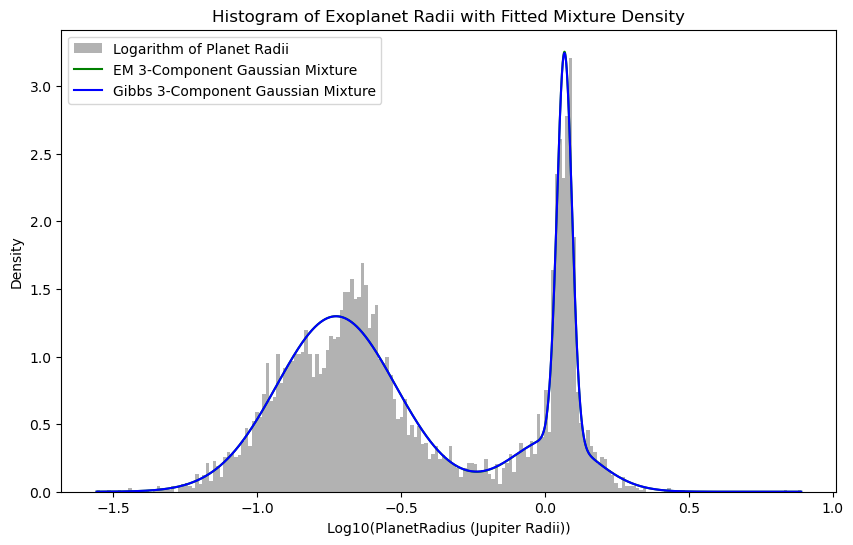

In [ ]:
K = 3
em_full = em_gmm_k(lograd, K=K, n_iter=10000, random_seed=4)

# EM converges to a single point estimate — no burnin needed, just take the last iteration
weights_em = em_full["weights"][-1]
mus_em     = em_full["mus"][-1]
sigmas_em  = em_full["sigmas"][-1]

print("EM weights:", weights_em)
print("EM means:", mus_em)
print("EM standard deviations:", sigmas_em)

x = np.linspace(lograd.min(), lograd.max(), 10000)
pdf_em_K = sum(
    weights_em[k] * norm.pdf(x, loc=mus_em[k], scale=sigmas_em[k])
    for k in range(K)
)

plt.figure(figsize=(10, 6))
plt.hist(lograd, bins=200, density=True, alpha=0.6,
         label='Logarithm of Planet Radii', color='gray')
plt.plot(x, pdf_em_K,    color='green', label=f'EM {K}-Component Gaussian Mixture')
plt.plot(x, pdf_gibbs_K, color='blue',  label=f'Gibbs {K}-Component Gaussian Mixture')
plt.title('Histogram of Exoplanet Radii with Fitted Mixture Density')
plt.xlabel('Log10(PlanetRadius (Jupiter Radii))')
plt.ylabel('Density')
plt.legend()
plt.show()

In this case, the EM fit and the fit corresponding to the posterior means for the Gibbs sampler are basically the same. 